In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
df = pd.read_csv("../train_transaction.csv")

print("Shape :", df.shape)
df.head()

Shape : (590540, 394)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 1.7+ GB


In [3]:
df['isFraud'].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [4]:
df['isFraud'].mean()

np.float64(0.03499000914417313)

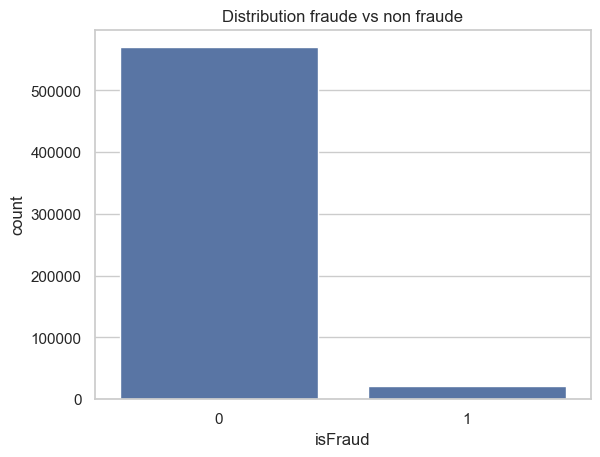

In [5]:
sns.countplot(x='isFraud', data=df)
plt.title("Distribution fraude vs non fraude")
plt.show()

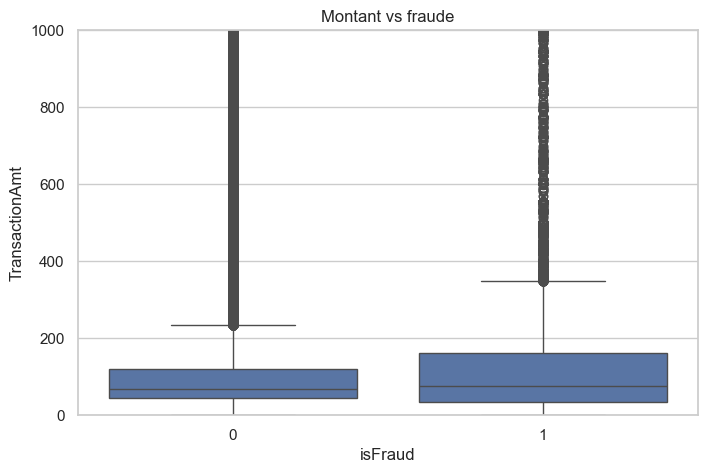

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='isFraud', y='TransactionAmt', data=df)
plt.ylim(0, 1000)
plt.title("Montant vs fraude")
plt.show()

In [7]:
missing = df.isnull().mean().sort_values(ascending=False)
missing.head(10)

dist2    0.936284
D7       0.934099
D13      0.895093
D14      0.894695
D12      0.890410
D6       0.876068
D9       0.873123
D8       0.873123
V153     0.861237
V149     0.861237
dtype: float64

In [8]:
num_df = df.select_dtypes(include=['number'])

corr = num_df.corr()

print(corr['isFraud'].sort_values(ascending=False).head(10))

isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
Name: isFraud, dtype: float64


In [9]:
# Supprimer colonnes avec trop de NaN
threshold = 0.9
df_clean = df.loc[:, df.isnull().mean() < threshold]

print("Nouvelle shape :", df_clean.shape)

Nouvelle shape : (590540, 392)


In [10]:
df_clean = df_clean.fillna(0)

In [11]:
X = df_clean.drop(columns=['isFraud'])
y = df_clean['isFraud']

print(X.shape, y.shape)

(590540, 391) (590540,)


In [12]:
df_clean = df.copy()

# Supprimer colonnes avec trop de NaN
df_clean = df_clean.loc[:, df_clean.isnull().mean() < 0.9]

# Remplir NaN
df_clean = df_clean.fillna(0)

In [13]:
X = df_clean.drop(columns=['isFraud'])
y = df_clean['isFraud']

In [14]:
cat_cols = X.select_dtypes(include=['object']).columns

from sklearn.preprocessing import LabelEncoder

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=10  # IMPORTANT pour imbalance
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [17]:
import pandas as pd

# importance du modèle
importances = model.feature_importances_

# créer dataframe
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
})

# garder top 20
top_features = feat_imp.sort_values(by='importance', ascending=False).head(20)['feature']

X_small = X[top_features]

In [18]:
X_sample = X_small.sample(200, random_state=42)

PermutationExplainer explainer: 101it [00:58,  1.72it/s]                         


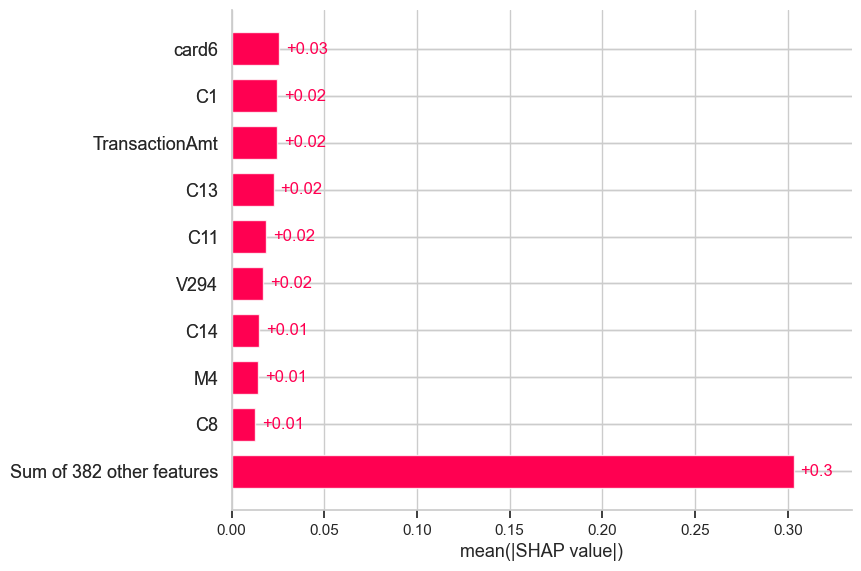

In [19]:
import shap

# 🔹 1. Sample avec toutes les colonnes (IMPORTANT)
X_sample = X_test.sample(100, random_state=42)

# 🔹 2. Explainer avec predict_proba
explainer = shap.Explainer(model.predict_proba, X_sample)

# 🔹 3. Calcul SHAP
shap_values = explainer(X_sample, max_evals=1000)

# 🔹 4. PRENDRE SEULEMENT LA CLASSE FRAUDE (index 1)
shap_values_fraud = shap_values[:, :, 1]

# 🔹 5. Visualisation
shap.plots.bar(shap_values_fraud)

In [21]:
import mlflow
import mlflow.xgboost
from sklearn.metrics import recall_score, precision_score, f1_score
import xgboost as xgb

# =========================
# 1. MLflow config
# =========================
mlflow.set_tracking_uri("http://127.0.0.1:5000")

# IMPORTANT : forcer l'utilisation EXACTE de l'experiment existant
mlflow.set_experiment("fraud-detection")

# =========================
# 2. MODEL
# =========================
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    eval_metric="logloss"
)

# =========================
# 3. RUN
# =========================
with mlflow.start_run():

    print("Run MLflow démarré")

    # TRAIN
    model.fit(X_train, y_train)

    # PRED
    y_pred = model.predict(X_test)

    # METRICS
    mlflow.log_metric("recall", recall_score(y_test, y_pred, zero_division=0))
    mlflow.log_metric("precision", precision_score(y_test, y_pred, zero_division=0))
    mlflow.log_metric("f1_score", f1_score(y_test, y_pred, zero_division=0))

    # PARAMS
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.1)

    # MODEL 
    mlflow.xgboost.log_model(model, name="model")

    print("Run enregistré correctement")

Run MLflow démarré
Run enregistré correctement
🏃 View run classy-stork-824 at: http://127.0.0.1:5000/#/experiments/1/runs/115e51ff80ce4fb288eb16585ce8bbe6
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


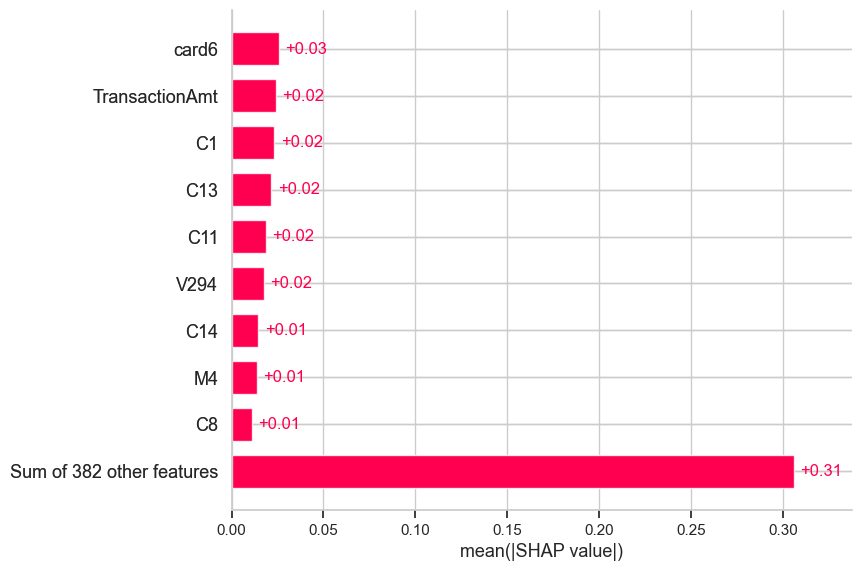

In [ ]:
# Juste avant la fin de ton "with mlflow.start_run():"
import matplotlib.pyplot as plt

# Sauvegarder le plot SHAP en image
shap.plots.bar(shap_values_fraud, show=False)
plt.savefig("shap_summary.png")
mlflow.log_artifact("shap_summary.png")